In [15]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import MemorySaver

In [16]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [17]:
llm = ChatGroq(model = "qwen/qwen3-32b")


def chat_node(state: ChatState):

    # take user query from state
    messages = state['messages']

    # send to llm
    response = llm.invoke(messages)

    # response store state
    return {'messages': [response]}

In [18]:
graph = StateGraph(ChatState)

# add nodes
graph.add_node('chat_node', chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)
checkpointer = MemorySaver()
chatbot = graph.compile(checkpointer=checkpointer)

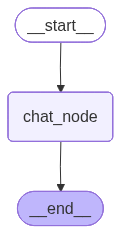

In [19]:
chatbot

In [20]:
config = {"configurable": {"thread_id": "1"}}

In [21]:

initial_state = {
    'messages': [HumanMessage(content='What is the capital of india')]
}

# chatbot.invoke(initial_state)['messages'][-1].content
response = chatbot.invoke(initial_state, config =config)
# ['messages'][-1].content
response

{'messages': [HumanMessage(content='What is the capital of india', additional_kwargs={}, response_metadata={}, id='8262e66c-b54d-4f27-a59c-95e50b5668b1'),
  AIMessage(content='<think>\nOkay, so the user is asking, "What is the capital of India?" Let me start by recalling what I know about India\'s capital. I remember that New Delhi is the capital, but wait, there\'s also a part about the historical context. I think Delhi was the capital before, and then it became New Delhi. Maybe the British built New Delhi as the capital in the early 20th century? I should check that.\n\nAlso, there\'s the aspect of the Indian government structure. The capital should be the seat of the national government, where the President, Parliament, and other key government offices are located. New Delhi is part of the Delhi region, which is a union territory. I need to confirm if New Delhi is a separate city or part of Delhi. From what I recall, Delhi is a larger area, and New Delhi is a specific part of it tha

In [22]:
response['messages']

[HumanMessage(content='What is the capital of india', additional_kwargs={}, response_metadata={}, id='8262e66c-b54d-4f27-a59c-95e50b5668b1'),
 AIMessage(content='<think>\nOkay, so the user is asking, "What is the capital of India?" Let me start by recalling what I know about India\'s capital. I remember that New Delhi is the capital, but wait, there\'s also a part about the historical context. I think Delhi was the capital before, and then it became New Delhi. Maybe the British built New Delhi as the capital in the early 20th century? I should check that.\n\nAlso, there\'s the aspect of the Indian government structure. The capital should be the seat of the national government, where the President, Parliament, and other key government offices are located. New Delhi is part of the Delhi region, which is a union territory. I need to confirm if New Delhi is a separate city or part of Delhi. From what I recall, Delhi is a larger area, and New Delhi is a specific part of it that was planned 

In [23]:
response['messages'][-1]

AIMessage(content='<think>\nOkay, so the user is asking, "What is the capital of India?" Let me start by recalling what I know about India\'s capital. I remember that New Delhi is the capital, but wait, there\'s also a part about the historical context. I think Delhi was the capital before, and then it became New Delhi. Maybe the British built New Delhi as the capital in the early 20th century? I should check that.\n\nAlso, there\'s the aspect of the Indian government structure. The capital should be the seat of the national government, where the President, Parliament, and other key government offices are located. New Delhi is part of the Delhi region, which is a union territory. I need to confirm if New Delhi is a separate city or part of Delhi. From what I recall, Delhi is a larger area, and New Delhi is a specific part of it that was planned as the capital. \n\nI should make sure there\'s no confusion with other cities. Sometimes people might confuse it with Mumbai or another city, 

In [24]:
response['messages'][-1].content

'<think>\nOkay, so the user is asking, "What is the capital of India?" Let me start by recalling what I know about India\'s capital. I remember that New Delhi is the capital, but wait, there\'s also a part about the historical context. I think Delhi was the capital before, and then it became New Delhi. Maybe the British built New Delhi as the capital in the early 20th century? I should check that.\n\nAlso, there\'s the aspect of the Indian government structure. The capital should be the seat of the national government, where the President, Parliament, and other key government offices are located. New Delhi is part of the Delhi region, which is a union territory. I need to confirm if New Delhi is a separate city or part of Delhi. From what I recall, Delhi is a larger area, and New Delhi is a specific part of it that was planned as the capital. \n\nI should make sure there\'s no confusion with other cities. Sometimes people might confuse it with Mumbai or another city, but those are majo

In [25]:
while True:

    user_message = input('Type here: ')
    print('User:', user_message)
    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
        break
    response = chatbot.invoke({'messages': [HumanMessage(content=user_message)]}, config=config)
    print('AI:', response['messages'][-1].content)


User: Hi I am Vaibhav
AI: <think>
Okay, the user just introduced himself as Vaibhav. Let me see how to respond.

First, the previous interaction was about the capital of India. I provided a detailed answer, so now it's a new conversation. The user says "Hi I am Vaibhav" which is a simple introduction. I need to acknowledge him and offer assistance.

I should make the response friendly and open-ended. Maybe start with a greeting like "Hello, Vaibhav!" to be personable. Then, ask how I can assist him today. Keeping it simple and welcoming is key here. No need for any complex language or additional information unless he asks for it. Just a standard reply to encourage further questions or discussions.
</think>

Hello, Vaibhav! 😊 How can I assist you today?
User: What is my name?
AI: <think>
Okay, the user asked, "What is my name?" after I previously asked them. Let me check the history.

In the previous message, the user introduced themselves as Vaibhav. Then I asked for their name, and th